In [1]:
import pandas as pd
import seaborn as sns

In [2]:
df = pd.read_csv("customer_shopping_behavior.csv")


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   str    
 3   Item Purchased          3900 non-null   str    
 4   Category                3900 non-null   str    
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   str    
 7   Size                    3900 non-null   str    
 8   Color                   3900 non-null   str    
 9   Season                  3900 non-null   str    
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   str    
 12  Shipping Type           3900 non-null   str    
 13  Discount Applied        3900 non-null   str    
 14  Promo Code Used         3900 non-null   str    
 15

In [4]:
df.describe( include="all")

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
count,3900.000000,3900.000000,3900,3900,3900,3900.000000,3900,3900,3900,3900,3863.000000,3900,3900,3900,3900,3900.000000,3900,3900
unique,NaN,NaN,2,25,4,NaN,50,4,25,4,NaN,2,6,2,2,NaN,6,7
top,NaN,NaN,Male,Blouse,Clothing,NaN,Montana,M,Olive,Spring,NaN,No,Free Shipping,No,No,NaN,PayPal,Every 3 Months
freq,NaN,NaN,2652,171,1737,NaN,96,1755,177,999,NaN,2847,675,2223,2223,NaN,677,584
mean,1950.500000,44.068462,NaN,NaN,NaN,59.764359,NaN,NaN,NaN,NaN,3.750065,NaN,NaN,NaN,NaN,25.351538,NaN,NaN
std,1125.977353,15.207589,NaN,NaN,NaN,23.685392,NaN,NaN,NaN,NaN,0.716983,NaN,NaN,NaN,NaN,14.447125,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,975.750000,31.000000,NaN,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,13.000000,NaN,NaN
50%,1950.500000,44.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,25.000000,NaN,NaN
75%,2925.250000,57.000000,NaN,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,NaN,NaN,38.000000,NaN,NaN


In [5]:
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

<Axes: xlabel='Review Rating', ylabel='Count'>

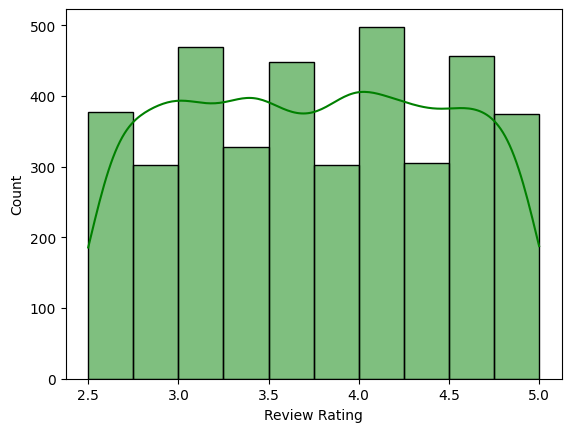

In [6]:
sns.histplot( df["Review Rating"], bins= 10, kde = True, color= "green")

In [7]:
df['Review Rating'] = (
    df.groupby('Category')['Review Rating']
    .transform(lambda x: x.fillna( x.median() ))
)

In [8]:
df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

In [9]:
df.columns = df.columns.str.lower().str.replace(" ", "_")
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount_(usd)', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='str')

In [10]:
df = df.rename( columns={"purchase_amount_(usd)": "purchase_amount"})
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='str')

In [11]:
print("max aged:", df['age'].max())
print("min aged:", df['age'].min())

max aged: 70
min aged: 18


In [12]:
# creating new col - age_group
label = ['young', 'adult', 'middle-aged', 'senior']
df['age_group'] = pd.qcut( x= df['age'], q = 4, labels = label)


In [13]:
df[['age', 'age_group']].head(10)

,age,age_group
0,55,middle-aged
1,19,young
2,50,middle-aged
3,21,young
4,45,middle-aged
5,46,middle-aged
6,63,senior
7,27,young
8,26,young
9,57,middle-aged


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   customer_id             3900 non-null   int64   
 1   age                     3900 non-null   int64   
 2   gender                  3900 non-null   str     
 3   item_purchased          3900 non-null   str     
 4   category                3900 non-null   str     
 5   purchase_amount         3900 non-null   int64   
 6   location                3900 non-null   str     
 7   size                    3900 non-null   str     
 8   color                   3900 non-null   str     
 9   season                  3900 non-null   str     
 10  review_rating           3900 non-null   float64 
 11  subscription_status     3900 non-null   str     
 12  shipping_type           3900 non-null   str     
 13  discount_applied        3900 non-null   str     
 14  promo_code_used         3900 non-nu

In [15]:
df[['discount_applied', 'promo_code_used']].head(10)

,discount_applied,promo_code_used
0,Yes,Yes
1,Yes,Yes
2,Yes,Yes
3,Yes,Yes
4,Yes,Yes
5,Yes,Yes
6,Yes,Yes
7,Yes,Yes
8,Yes,Yes
9,Yes,Yes


In [16]:
(df['discount_applied'] == df['promo_code_used']).all()

np.True_

In [17]:
df = df.drop( 'promo_code_used', axis=1)

In [18]:
df['frequency_of_purchases'].unique()

<StringArray>
[   'Fortnightly',         'Weekly',       'Annually',      'Quarterly',
      'Bi-Weekly',        'Monthly', 'Every 3 Months']
Length: 7, dtype: str

In [19]:
# craating frquecny of purchanse days column

frequency_mapping = {
    'Fortnightly': 14,
    'Weekly': 7,
    'Bi-Weekly': 14,
    'Monthly': 30,
    'Every 3 Months': 90,
    'Quarterly':120,
    'Annually':365
}

df['frequency_of_purchases_days'] = df['frequency_of_purchases'].map( frequency_mapping )

df[['frequency_of_purchases', 'frequency_of_purchases_days']].head(10)

,frequency_of_purchases,frequency_of_purchases_days
0,Fortnightly,14
1,Fortnightly,14
2,Weekly,7
3,Weekly,7
4,Annually,365
5,Weekly,7
6,Quarterly,120
7,Weekly,7
8,Annually,365
9,Quarterly,120


In [20]:
df.head()

,customer_id,age,gender,item_purchased,category,purchase_amount,location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,previous_purchases,payment_method,frequency_of_purchases,age_group,frequency_of_purchases_days
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,14,Venmo,Fortnightly,middle-aged,14
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,2,Cash,Fortnightly,young,14
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,23,Credit Card,Weekly,middle-aged,7
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,49,PayPal,Weekly,young,7
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,31,PayPal,Annually,middle-aged,365


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   customer_id                  3900 non-null   int64   
 1   age                          3900 non-null   int64   
 2   gender                       3900 non-null   str     
 3   item_purchased               3900 non-null   str     
 4   category                     3900 non-null   str     
 5   purchase_amount              3900 non-null   int64   
 6   location                     3900 non-null   str     
 7   size                         3900 non-null   str     
 8   color                        3900 non-null   str     
 9   season                       3900 non-null   str     
 10  review_rating                3900 non-null   float64 
 11  subscription_status          3900 non-null   str     
 12  shipping_type                3900 non-null   str     
 13  discount_appli

In [25]:
df['shipping_type'].unique()

<StringArray>
[       'Express',  'Free Shipping',   'Next Day Air',       'Standard',
 '2-Day Shipping',   'Store Pickup']
Length: 6, dtype: str

In [22]:
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

load_dotenv()

DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

url = URL.create(
    drivername="postgresql",
    username=DB_USER,
    password=DB_PASSWORD,
    host=DB_HOST,
    port=DB_PORT,
    database=DB_NAME
)

engine = create_engine(url)

with engine.connect() as conn:
    print("Connected successfully")


Connected successfully


In [23]:
df.to_sql(
    name='customer_shopping_behavior',
    con=engine,
    if_exists='replace',
    index= False
)

900